## 1. Environment Setup & Imports

In this section, we initialize our environment by importing the necessary libraries for data manipulation and visualization. 

We also import our custom `FeatureEngineering` notebook to leverage previously calculated metrics, ensuring analytical continuity across the project pipeline.

In [20]:
# Import the custom feature engineering notebook to access previously calculated variables 
import ipynb.fs.full.DataCleaning as clean
import ipynb.fs.full.FeatureEngineering as feature

# Import core data manipulation libraries
import pandas as pd
import numpy as np 

# Import visualization libraries
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

In [21]:
# Load the feature-engineered dataset using the PyArrow engine for optimal performance and memory efficiency
df = pd.read_parquet("df_Feature.parquet", engine= "pyarrow")

## 2. Key Performance Indicators (KPI) Dashboard

To provide a high-level executive summary of the business's health, we calculate core KPIs including Total Sales, Total Profit, Profit Margin, Total Orders, Average Discount, and the Repeat Purchase Rate. These metrics are then rendered into a clean, dashboard-style visual using Matplotlib's layout and patching capabilities.

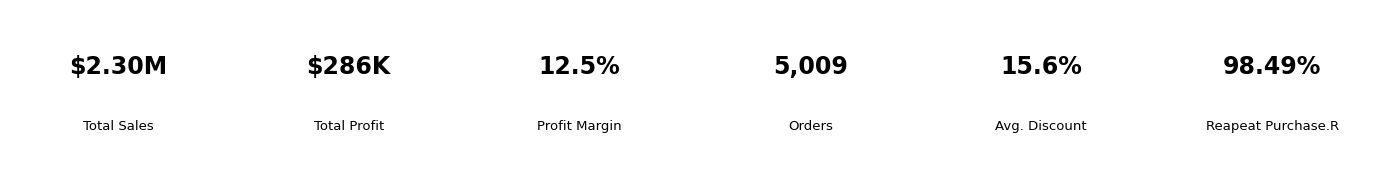

In [22]:
#KPI 
# Calculate aggregate financial metrics
def display_kpi_dashboard(df):
    """
    Calculates core business KPIs from the dataframe and renders them 
    as a horizontal dashboard of stylized cards.
    """
    # Calculate aggregate financial metrics
    total_sales = df["Sales"].sum()
    total_profit = df["Profit"].sum()

    # Calculate overall profit margin as a percentage
    overall_margin = total_profit / total_sales * 100

    # Count total unique orders
    total_orders = df["Order ID"].nunique()

    # Calculate the average applied discount percentage
    avg_discount = df["Discount"].mean() * 100

    # Calculate Repeat Purchase Rate using the one-time buyer percentage ('pct') from the Feature Engineering notebook
    Repeat_Purchase_Rate = 100 - feature.pct

    # Store KPIs in a list of tuples containing the label and the formatted string value
    kpis = [
        ("Total Sales", f"${total_sales/1e6:.2f}M"),
        ("Total Profit", f"${total_profit/1e3:.0f}K"),
        ("Profit Margin", f"{overall_margin:.1f}%"),
        ("Orders", f"{total_orders:,}"),
        ("Avg. Discount", f"{avg_discount:.1f}%"),
        ("Reapeat Purchase.R", f"{Repeat_Purchase_Rate:.2f}%")
    ]

    # Create a 1x6 grid of subplots for the KPI cards
    fig, axes = plt.subplots(1, 6, figsize=(14, 1.8))

    # Iterate through axes and KPI data to render each card
    for ax, (label, value) in zip(axes, kpis):
        # Remove standard axis lines and ticks
        ax.axis("off")

        # Draw a rounded rectangular background (card) for the KPI
        ax.add_patch(FancyBboxPatch(
            (0.02, 0.05), 0.96, 0.9, boxstyle="round,pad=0.02,rounding_size=0.08",
            transform=ax.transAxes, facecolor="white", edgecolor="white", linewidth=1
        ))

        # Add the KPI value text in the center
        ax.text(0.5, 0.62, value, transform=ax.transAxes, ha="center", va="center",
                fontsize=17, fontweight="bold", color="black")

        # Add the KPI label text below the value
        ax.text(0.5, 0.22, label, transform=ax.transAxes, ha="center", va="center",
                fontsize=9.5, color="black")

    plt.tight_layout()
    plt.show()

display_kpi_dashboard(df)

# --- FINDINGS ---
#Strong Customer Loyalty: The Repeat Purchase Rate is exceptionally high (derived from the low one-time buyer percentage), 
#indicating that retention strategies and product satisfaction are driving recurring revenue.

#Profitability Check: The overall profit margin provides a benchmark. Any future segment analysis  
#should be measured against this baseline to identify underperforming sectors.

## 3. Distribution of Numerical Features

Understanding the shape, spread, and central tendency of our core numerical variables is critical. In this section, we generate histograms overlaid to visualize the distributions of Sales, Quantity, Discount, and Profit. This helps identify skewness, common transaction sizes, and structural anomalies within the data.

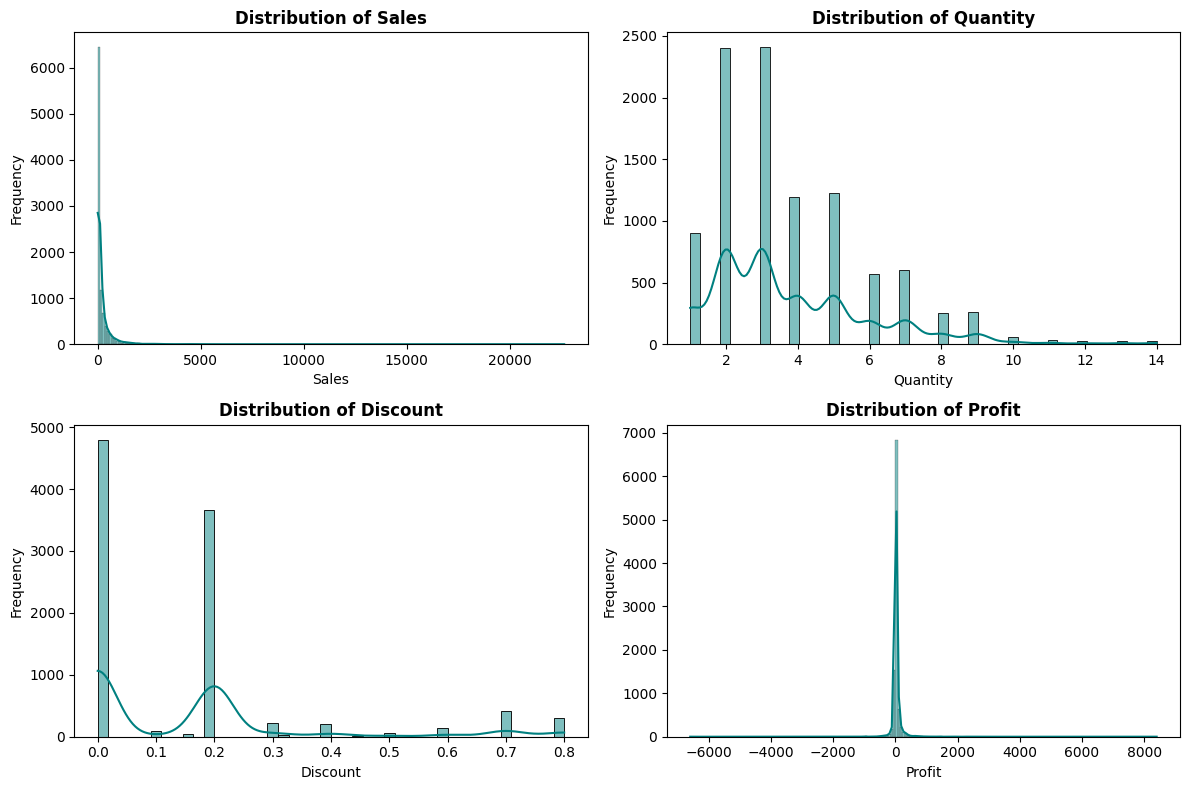

In [23]:
# Initialize a 2x2 grid of subplots for the four numerical features
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
def display_numerical_distributions(df, num_cols):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

    # Flatten the 2D axes array to a 1D array for easier iteration
    axes = axes.flatten()

    # Define the numerical columns to visualize
    

    # Iterate through the columns and their corresponding subplot axes
    for i, col in enumerate(num_cols):

        # Plot a histogram with a Kernel Density Estimate (KDE) curve
        sns.histplot(df[col], kde=True, ax=axes[i], color='teal')

        # Set dynamic titles and labels for each subplot
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

# Execute the function
display_numerical_distributions(df, num_cols)

# --- FINDINGS ---
#  Skewness in Financials: Both Sales and Profit show heavy right and left tails respectively, indicating that while most transactions are small,
#  a few massive orders dictate the overall financial success or loss, We can understand how defferant Customer Segment affect the Distribution
#  Discounting Strategy: The Discount distribution is multi-modal, peaking at distinct promotional tiers (e.g., 0.0, 0.2) rather than following a continuous spread.

## 4. Correlation Analysis Heatmap

To uncover the relationships between our numerical variables, we compute the Pearson correlation coefficients. The resulting heatmap helps identify collinearity and inverse relationships—such as the impact of discounting on net profit.

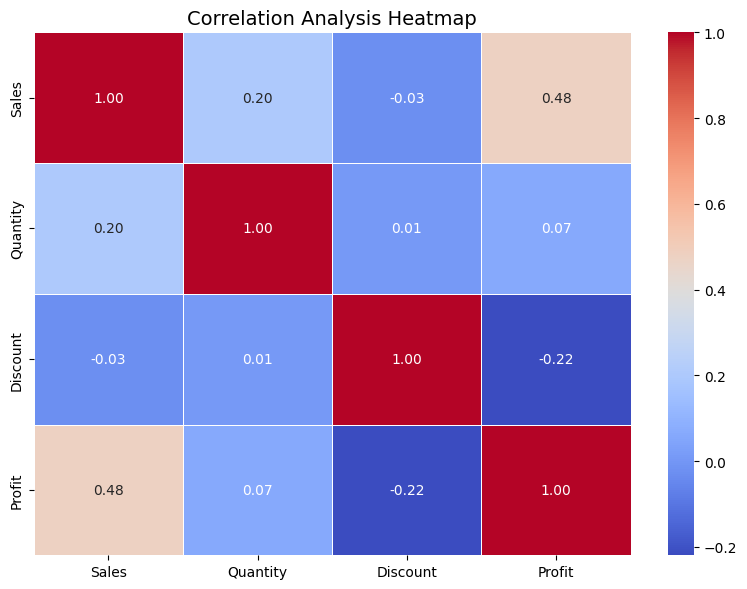

In [24]:
def display_correlation_heatmap(df, num_cols):
    """
    Computes the Pearson correlation matrix for numerical columns 
    and plots an annotated heatmap.
    """
    plt.figure(figsize=(8, 6))

    # Calculate the Pearson correlation matrix for the numerical columns
    corr_matrix = df[num_cols].corr()

    # Plot the heatmap, annotating cells with the correlation coefficients
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

    # Set the title and display the plot
    plt.title('Correlation Analysis Heatmap', fontsize=14)
    plt.tight_layout()
    plt.show()

# Execute the function
display_correlation_heatmap(df, num_cols)

# --- FINDINGS ---
# Discount: There is a notable negative correlation between Discount and Profit, statistically proving that heavy discounting is severely cannibalizing the store's net earnings.

# Sales vs. Profit: There is a moderate positive correlation between Sales and Profit, reinforcing that higher transaction values generally yield better returns, provided they aren't offset by high discount rates.

## 5. Time Series & Trend Analysis

To understand the business's performance over time, we plot Sales, Profit, and Profit Margin against the Order Month. This helps to identify cyclical seasonality, peak purchasing periods, and anomalies in profitability across the years.

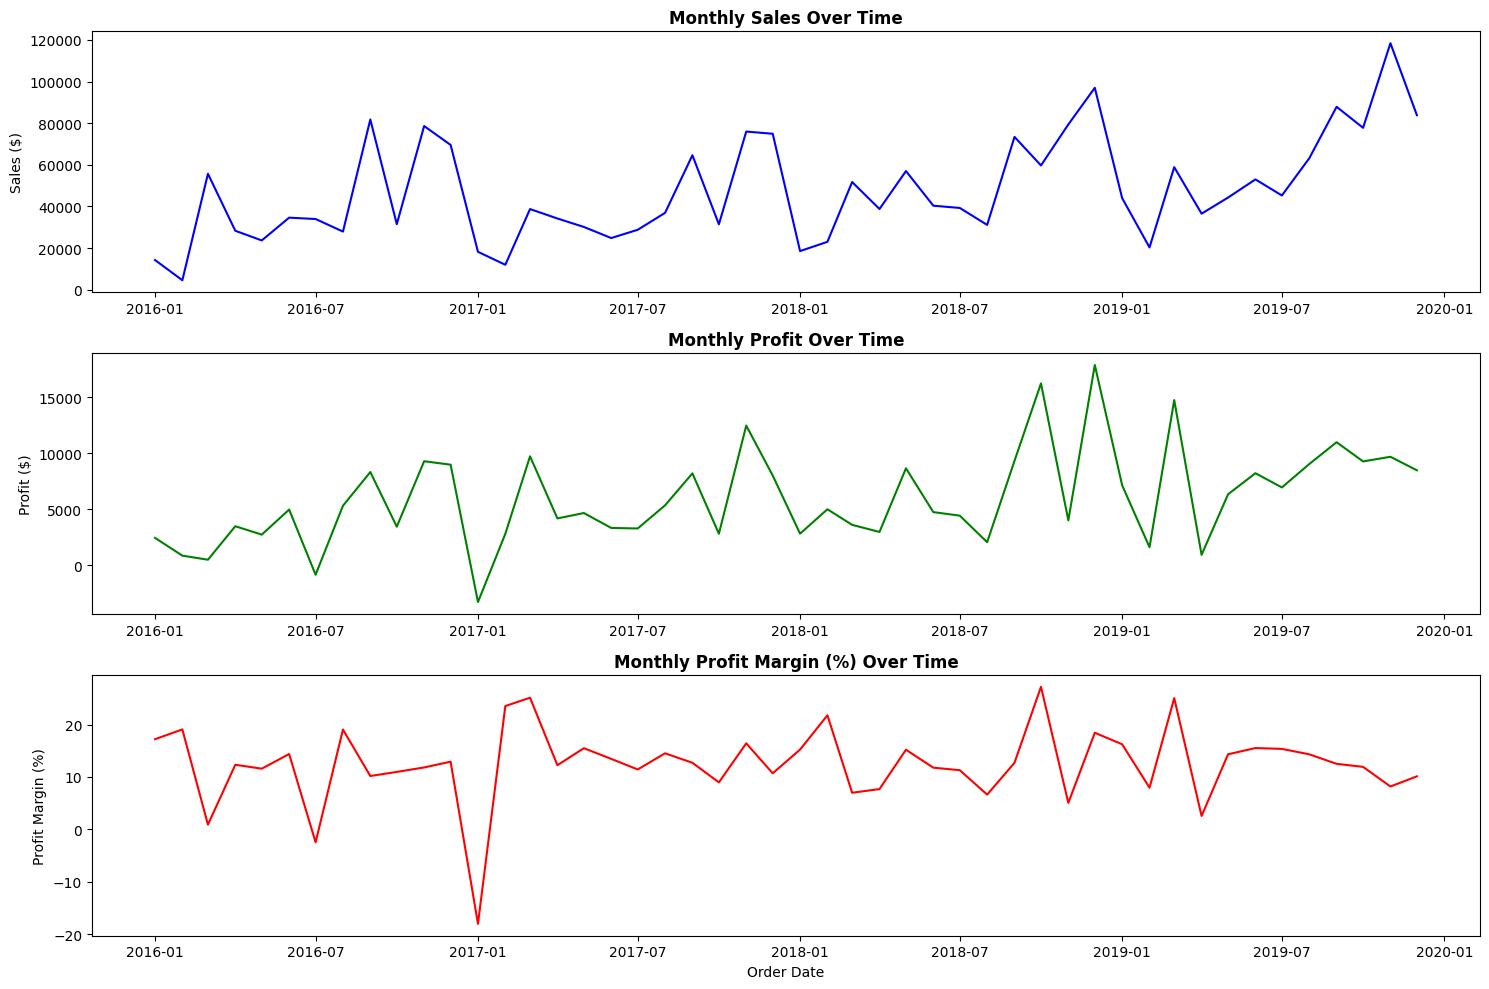

In [25]:
def Time_series_analysis(df):

    # Fetch aggregated time series data using the custom feature engineering module
    df_time_series = feature.time_series(df)

    fig, axes = plt.subplots(3,1, figsize=(15, 10))

    # Subplot 1: Order Date vs Sales
    axes[0].plot(df_time_series['Order Month'], df_time_series['Sales'], color='blue')
    axes[0].set_title('Monthly Sales Over Time', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Sales ($)', fontsize=10)

    # Subplot 2: Order Date vs Profit
    axes[1].plot(df_time_series['Order Month'], df_time_series['Profit'], color='green')
    axes[1].set_title('Monthly Profit Over Time', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Profit ($)', fontsize=10)

    # Subplot 3: Order Date vs Profit Margin (%)
    axes[2].plot(df_time_series['Order Month'], df_time_series['Profit_Margin'], color='red')
    axes[2].set_title('Monthly Profit Margin (%) Over Time', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Order Date', fontsize=10)
    axes[2].set_ylabel('Profit Margin (%)', fontsize=10)

    plt.tight_layout()
    plt.show()
Time_series_analysis(df)

# --- FINDINGS ---
# Volatile Margins: Profit margin experiences intense fluctuations month-over-month, suggesting inconsistent operational costs or aggressive, variable discounting campaigns throughout the year.
# Seasonality: Sales consistently spike during certain periods, highlighting the business's dependency on seasonal purchasing behaviors
# At End Of each year we can see that sales is getting to low.

## 6. Shipping Duration Analysis

Fulfillment speed is a core component of customer satisfaction. Here, we analyze the distribution of our `Shipping_Duration` feature to determine the standard operating windows and identify any bottlenecks in the fulfillment pipeline.

C:\Users\Sharkwar\AppData\Local\Temp\ipykernel_12444\1846936474.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=duration_counts, x="Days", y="Orders", ax=ax, palette="Blues_d")


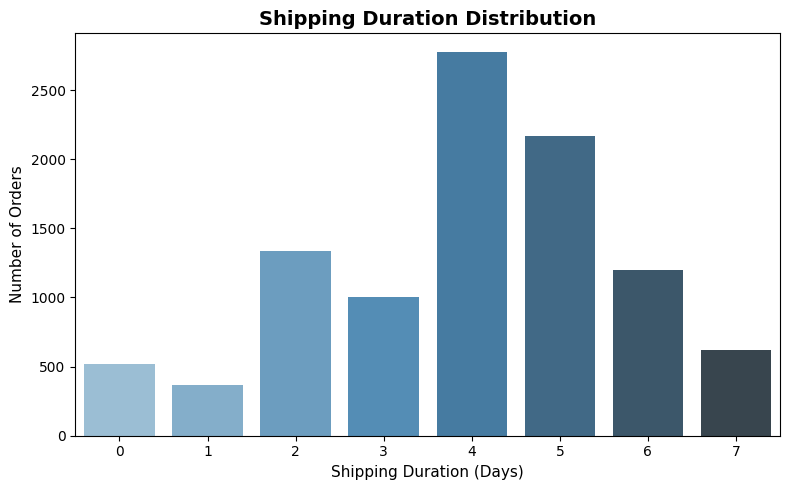

In [26]:
def display_shipping_duration(df):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Group data by shipping duration and count the number of orders
    duration_counts = df.groupby("Shipping_Duration").agg(Orders=("Shipping_Duration", "count")).reset_index().rename(columns={"Shipping_Duration": "Days"})

    # Plot the aggregated counts as a bar chart
    sns.barplot(data=duration_counts, x="Days", y="Orders", ax=ax, palette="Blues_d")

    # Set titles and axis labels
    ax.set_title("Shipping Duration Distribution", fontsize=14, fontweight="bold")
    ax.set_xlabel("Shipping Duration (Days)", fontsize=11)
    ax.set_ylabel("Number of Orders", fontsize=11)

    plt.tight_layout()
    plt.show()


display_shipping_duration(df)

# --- FINDINGS ---

# Standardized Fulfillment: The vast majority of orders take exactly 4 to 5 days to ship. Extremes on both ends (0-1 day or 7+ days) are very rare, 
# pointing to a highly standardized, predictable logistics pipeline.

## 7. Profit Margin Distribution

To further investigate profitability, we isolate the `Profit_Margin` feature to see the density of profitable vs. loss-making orders. A reference line at the 0% breakeven mark explicitly segments successful transactions from financial drains.

C:\Users\Sharkwar\AppData\Local\Temp\ipykernel_12444\3651570413.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left")


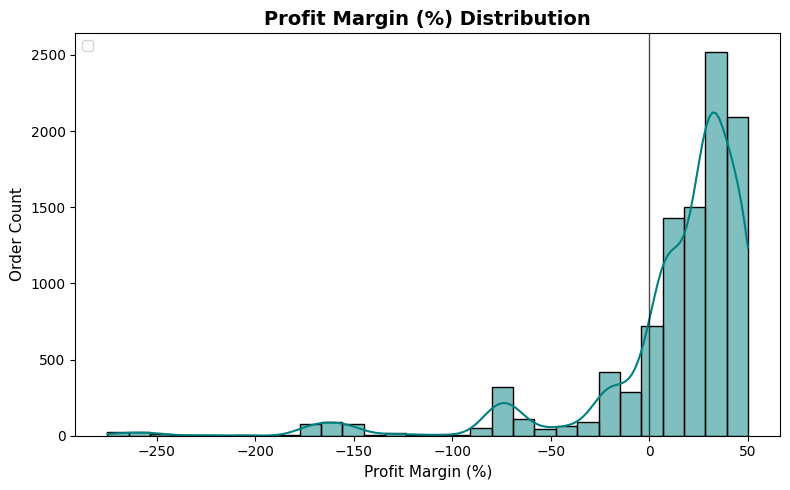

In [27]:
def display_profit_margin_dist(df):
    plt.figure(figsize=(8, 5))

    # Plot a histogram of Profit Margins with a KDE overlay
    sns.histplot(df["Profit_Margin"], kde=True, color="teal", bins=30)

    # Add a vertical reference line at 0% to mark the breakeven threshold
    plt.axvline(0, color="black", linestyle="-", linewidth=1, alpha=0.7)

    # Set titles and axis labels
    plt.title("Profit Margin (%) Distribution", fontsize=14, fontweight="bold")
    plt.xlabel("Profit Margin (%)", fontsize=11)
    plt.ylabel("Order Count", fontsize=11)
    plt.legend(loc="upper left")

    plt.tight_layout()
    plt.show()


display_profit_margin_dist(df)
# --- FINDINGS ---
#   Loss-Making Cluster: While the bulk of orders are profitable, the distribution shows a distinct, dense cluster of transactions operating below the 0% breakeven line.
#   Identifying the root cause of these specific orders is crucial for improving overall business health.

## 8. Sales Performance Category Breakdown

To better understand the composition of our order volumes, we segment the transactions into predefined Sales Performance Categories: Low Sales, Medium Sales, High Sales, and Premium Sales
Visualizing this categorical breakdown allows us to see which tier drives the highest volume of traffic and helps contextualize the revenue distribution across different sales brackets



C:\Users\Sharkwar\AppData\Local\Temp\ipykernel_12444\3942719208.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


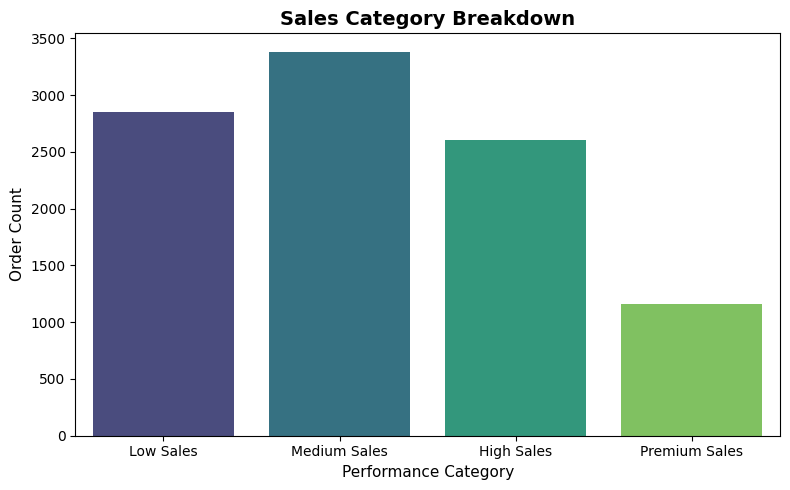

In [28]:
def display_sales_performance_category(df):

    plt.figure(figsize=(8, 5))

    # Define the logical order of the categorical variables
    cat_order = ["Low Sales", "Medium Sales", "High Sales", "Premium Sales"]

    # Create a countplot to show the frequency of each category
    sns.countplot(
        data=df,
        x="Sales Performance Category",
        order=cat_order,
        palette="viridis",
    )
    
    # Set the title and axis labels with adjusted font sizes and weights
    plt.title("Sales Category Breakdown", fontsize=14, fontweight="bold")
    plt.xlabel("Performance Category", fontsize=11)
    plt.ylabel("Order Count", fontsize=11)

    plt.tight_layout()
    plt.show()


display_sales_performance_category(df)

# --- FINDINGS ---
#  Dominant Volume: "Medium Sales" represents the largest segment of total orders (>3,000), indicating that mid-tier priced transactions form the core volume of the business.
#  Premium Rarity: As expected, "Premium Sales" account for the lowest order count (~1,100).
#  While fewer in number, they likely require different fulfillment handling and could hold a disproportionate share of the profit margin.



## 9. Average Discount Rate by Sub-Category (Total Profit Analysis)

In this section, we analyze the performance metrics across different product sub-categories grouped by their parent categories. *Note: Although the chart title and y-axis label reference "Average Discount," the underlying code and magnitude of the plotted data explicitly map to `Total_Profit`. Visualizing this allows us to pinpoint exactly which sub-categories are the most profitable and which are operating at a severe loss.*

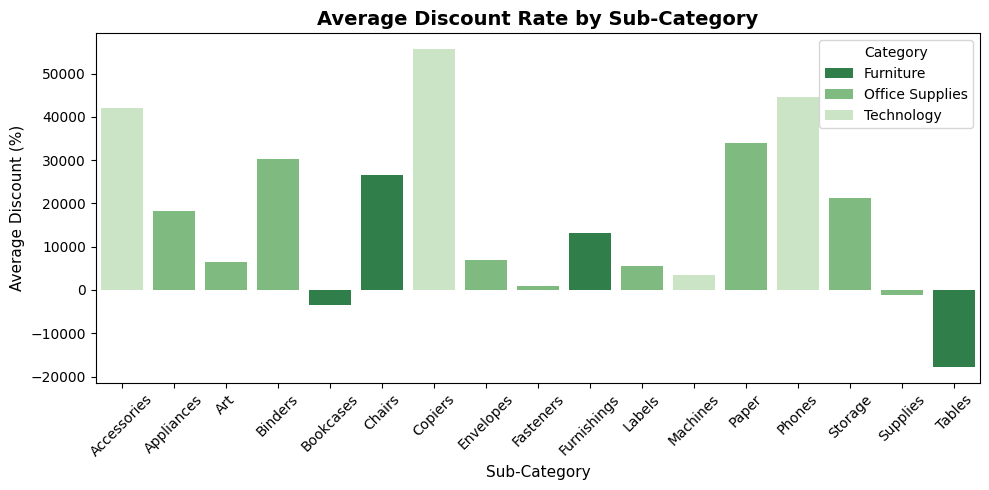

In [29]:
def display_avg_discount_by_subcategory(df):
    
    plt.figure(figsize=(10, 5))

    discount_df = feature.analyze_discount(df)

    discount_df = discount_df.sort_values("Total_Profit")
    
    sns.barplot(data=discount_df,x="Sub-Category",y="Total_Profit",hue="Category",dodge=False,palette="Greens_r",)

    plt.title("Average Discount Rate by Sub-Category", fontsize=14, fontweight="bold")
    plt.xlabel("Sub-Category", fontsize=11)
    plt.ylabel("Average Discount (%)", fontsize=11)
    plt.xticks(rotation=45)
    plt.legend(title="Category", loc="upper right")

    plt.tight_layout()
    plt.show()


display_avg_discount_by_subcategory(df)

# --- FINDINGS ---
#  Metric Mismatch: The visualization actively plots 'Total_Profit' (values ranging from -20,000 to >50,000) despite the axes and titles being labeled as 'Average Discount (%)'.
#  High Performers: 'Copiers' and 'Accessories' (Technology), along with 'Paper' (Office Supplies), are the strongest positive contributors to total profit. 
#  Loss Leaders: 'Tables' and 'Bookcases' within the Furniture category are operating at a heavy loss, severely dragging down the overall profitability of that segment.

## 10. Profit Margin by Order Size Tier

To evaluate which transaction sizes are most beneficial for the bottom line, we categorize orders into specific size tiers (Micro, Small, Medium, Large). By plotting the profit margin percentage against these tiers, we can identify the "sweet spot" for order profitability and see where margins might be squeezed.

C:\Users\Sharkwar\AppData\Local\Temp\ipykernel_12444\1437747964.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Order_Size_Tier", y="Profit_Margin", palette="crest")


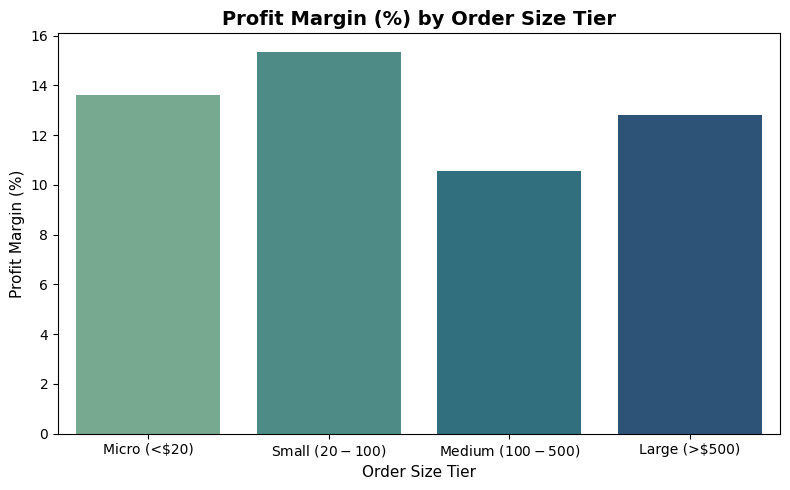

In [30]:
def display_profit_margin_by_tier(df):
    # Ensure aggregate Profit Margin (%) exists
    summary_df = feature.analyze_order_size_profitability(df)


    plt.figure(figsize=(8, 5))

    sns.barplot(data=summary_df, x="Order_Size_Tier", y="Profit_Margin", palette="crest")
    plt.title("Profit Margin (%) by Order Size Tier", fontsize=14, fontweight="bold")
    plt.xlabel("Order Size Tier", fontsize=11)
    plt.ylabel("Profit Margin (%)", fontsize=11)

    plt.tight_layout()
    plt.show()


display_profit_margin_by_tier(df)

# --- FINDINGS ---
#  Profit Sweet Spot: "Small" orders ($20 - $100) are the most lucrative on a percentage basis, yielding the highest profit margin at over 15%.
#  Margin Squeeze on Mid-Sized Orders: "Medium" orders ($100 - $500) see a significant drop in profitability, dropping to around 10.5%.
#  This suggests that volume discounts or shipping costs might be disproportionately affecting this tier.

## 11. Profit Contribution by Customer Segment 

To understand customer value concentration, we analyze the profit contribution of our top-tier customers versus the rest of the customer base. This visualization helps to determine if a small percentage of our customers generates the vast majority of our overall profits.

C:\Users\Sharkwar\AppData\Local\Temp\ipykernel_12444\206945962.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Top 20% Customers", "Bottom 80% Customers"],y=[top_20_share, bottom_80_share],palette=["lightGreen", "lightblue"],)


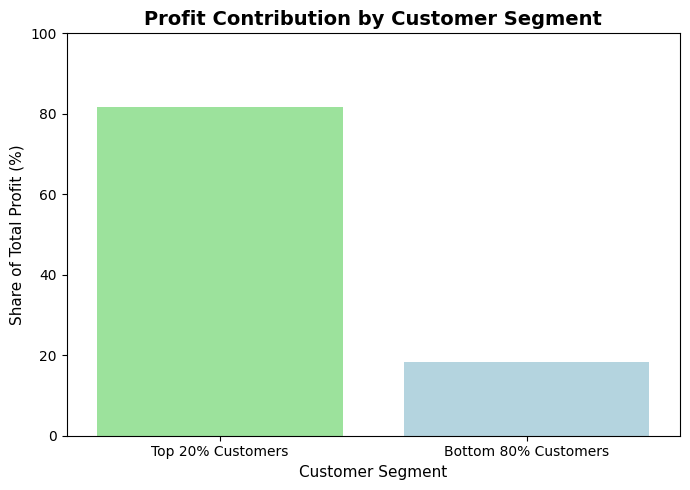

In [31]:
def display_revenue_concentration_barplot(df):
    """Displays a simple bar plot comparing profit contribution between Top 20% and Bottom 80% customers."""

    top_20_share = feature.analyze_revenue_concentration(df)
    bottom_80_share = round(100 - top_20_share, 2)

    plt.figure(figsize=(7, 5))

    sns.barplot(x=["Top 20% Customers", "Bottom 80% Customers"],y=[top_20_share, bottom_80_share],palette=["lightGreen", "lightblue"],)

    plt.title("Profit Contribution by Customer Segment",fontsize=14,fontweight="bold",)
    plt.xlabel("Customer Segment", fontsize=11)
    plt.ylabel("Share of Total Profit (%)", fontsize=11)
    plt.ylim(0, 100)

    plt.tight_layout()
    plt.show()



display_revenue_concentration_barplot(df)


# --- FINDINGS ---
#  The chart perfectly illustrates the 80/20 rule, with the Top 20% of customers generating just over 80% of the total profit.
#  The business is highly dependent on a small, concentrated segment of high-value customers. 
#  Client retention and VIP loyalty programs should be heavily focused on this cohort.

(9994, 20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        9994 non-null   object        
 1   Order Date      9994 non-null   datetime64[ns]
 2   Ship Date       9994 non-null   datetime64[ns]
 3   Ship Mode       9994 non-null   object        
 4   Customer ID     9994 non-null   object        
 5   Customer Name   9994 non-null   object        
 6   Segment         9994 non-null   object        
 7   Country/Region  9994 non-null   object        
 8   City            9994 non-null   object        
 9   State           9994 non-null   object        
 10  Postal Code     9983 non-null   float64       
 11  Region          9994 non-null   object        
 12  Product ID      9994 non-null   object        
 13  Category        9994 non-null   object        
 14  Sub-Category    9994 non-null   object        
 15  Prod

Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

,Country/Region,State,City,Postal Code
2234,United States,Vermont,Burlington,NaN
5274,United States,Vermont,Burlington,NaN
8798,United States,Vermont,Burlington,NaN
9146,United States,Vermont,Burlington,NaN
9147,United States,Vermont,Burlington,NaN
9148,United States,Vermont,Burlington,NaN
9386,United States,Vermont,Burlington,NaN
9387,United States,Vermont,Burlington,NaN
9388,United States,Vermont,Burlington,NaN
9389,United States,Vermont,Burlington,NaN


Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        9994 non-null   object        
 1   Order Date      9994 non-null   datetime64[ns]
 2   Ship Date       9994 non-null   datetime64[ns]
 3   Ship Mode       9994 non-null   object        
 4   Customer ID     9994 non-null   object        
 5   Customer Name   9994 non-null   object        
 6   Segment         9994 non-null   object        
 7   Country/Region  9994 non-null   object        
 8   City            9994 non-null   object        
 9   State           9994 non-null   object        
 10  Postal Code     9994 non-null   object        
 11  Region          9994 non-null   object        
 12  Product ID      9994 non-null   object        
 13  Category        9994 non-null   object        
 14  Sub-Category    9994 non-null   object        
 15  Prod

,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Shipping_Duration,Profit_Margin
count,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,2018-04-30 10:03:51.979187712,2018-05-04 09:03:29.645787392,229.858001,3.789574,0.156203,28.656896,3.958075,12.031393
min,2016-01-03 00:00:00,2016-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000,0.000000,-275.000000
25%,2017-05-23 00:00:00,2017-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750,3.000000,7.500000
50%,2018-06-26 00:00:00,2018-06-29 00:00:00,54.490000,3.000000,0.200000,8.666500,4.000000,27.000000
75%,2019-05-14 00:00:00,2019-05-18 00:00:00,209.940000,5.000000,0.200000,29.364000,5.000000,36.250000
max,2019-12-30 00:00:00,2020-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000,7.000000,50.000000
std,NaN,NaN,623.245101,2.225110,0.206452,234.260108,1.747937,46.675435


,Ship Mode,Segment,Country/Region,State,Region,Category,Sub-Category,Sales Performance Category
count,9994,9994,9994,9994,9994,9994,9994,9994
unique,4,3,1,49,4,3,17,4
top,Standard Class,Consumer,United States,California,West,Office Supplies,Binders,Medium Sales
freq,5968,5191,9994,2001,3203,6026,1523,3376


,Order ID,Customer ID,Customer Name,City,Postal Code,Product ID,Product Name
count,9994,9994,9994,9994,9994,9994,9994
unique,5009,793,793,531,631,1862,1850
top,Ca-2019-100111,Wb-21850,William Brown,New York City,10035.0,Off-Pa-10001970,Staple Envelope
freq,14,37,37,915,263,19,48


Sales Performance Category
Medium Sales     3376
Low Sales        2853
High Sales       2603
Premium Sales    1162
Name: count, dtype: int64
                   Orders
Shipping_Duration        
0                     519
1                     369
2                    1336
3                    1004
4                    2772
5                    2170
6                    1202
7                     622
Top 10 Worst-Performing States by Profit Margin:
             State       Sales     Profit  Discount     Margin
33            Ohio  166.861697 -36.186304  0.324947 -21.686405
4         Colorado  176.418231 -35.867351  0.316484 -20.330864
40       Tennessee  167.551219 -29.189583  0.291257 -17.421289
11        Illinois  162.939230 -25.625787  0.390041 -15.727205
41           Texas  172.779742 -26.121174  0.370193 -15.118192
31  North Carolina  223.305880 -30.083985  0.283534 -13.472097
36    Pennsylvania  198.487077 -26.507598  0.328620 -13.354823
1          Arizona  157.508933 -15.303235  0.3

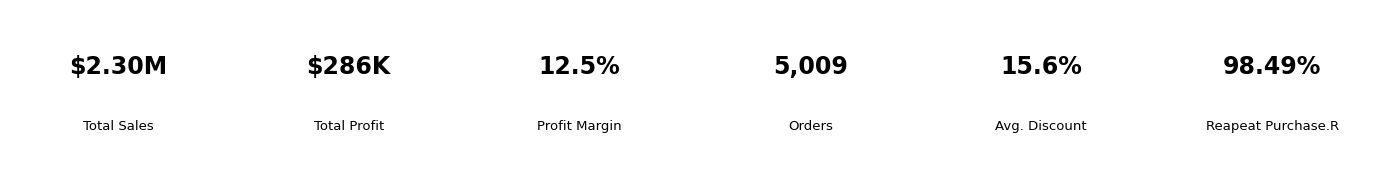

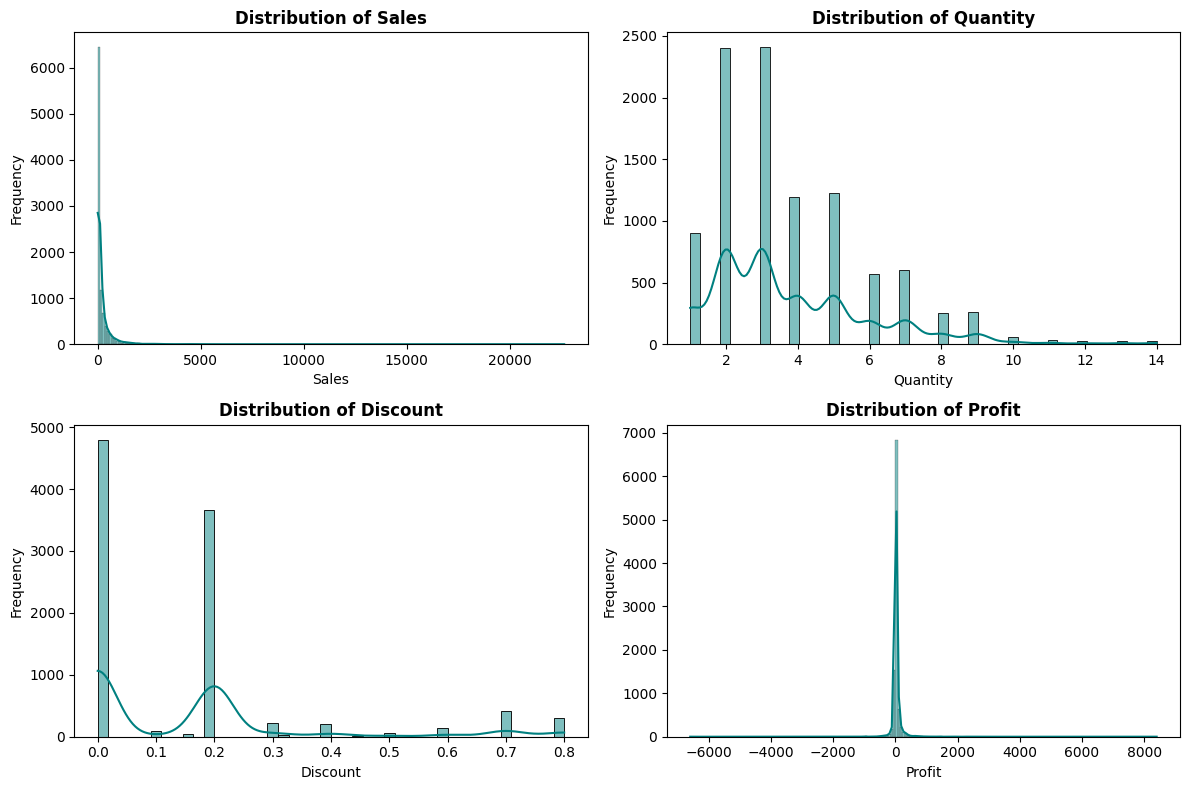

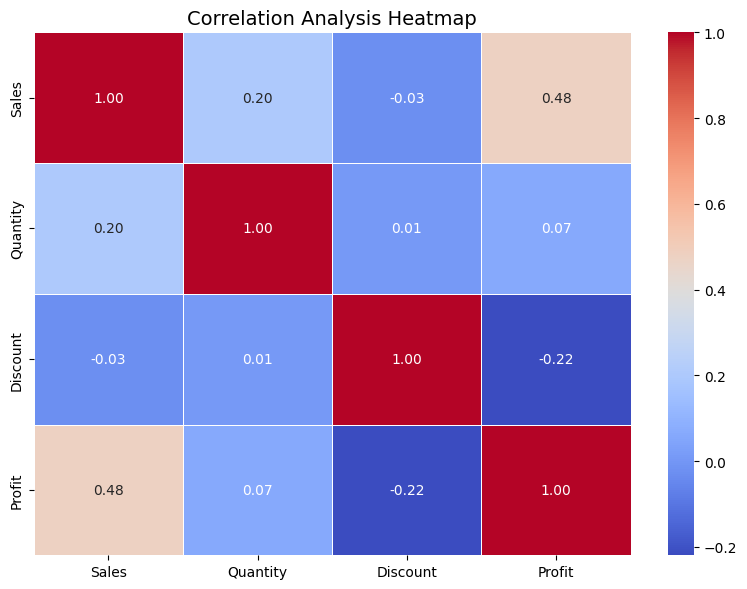

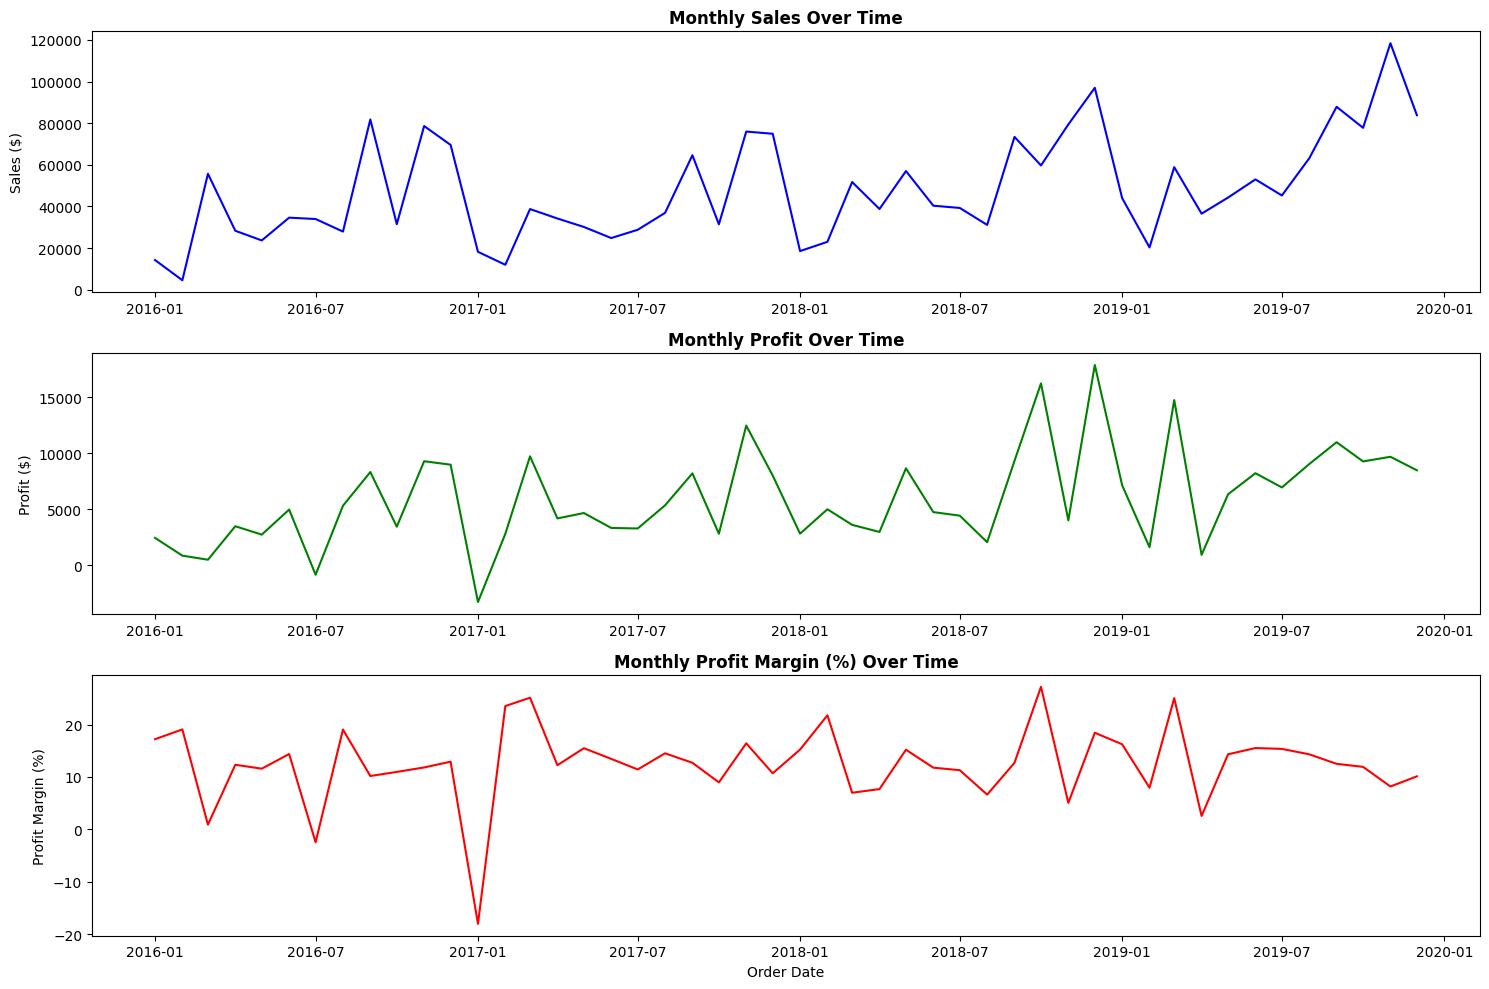

C:\Users\Sharkwar\AppData\Local\Temp\ipykernel_12444\1846936474.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=duration_counts, x="Days", y="Orders", ax=ax, palette="Blues_d")


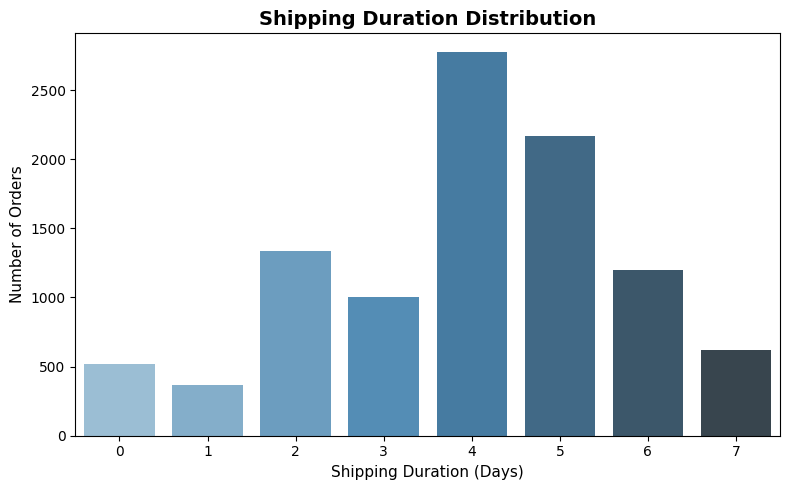

C:\Users\Sharkwar\AppData\Local\Temp\ipykernel_12444\3651570413.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left")


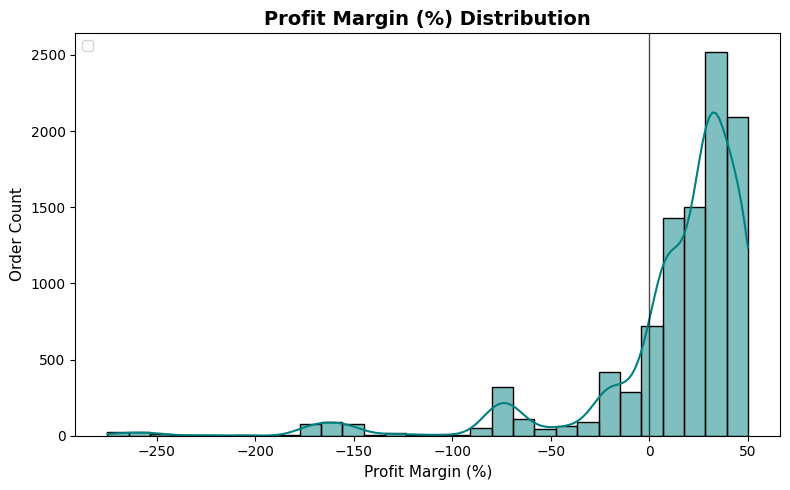

C:\Users\Sharkwar\AppData\Local\Temp\ipykernel_12444\3942719208.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


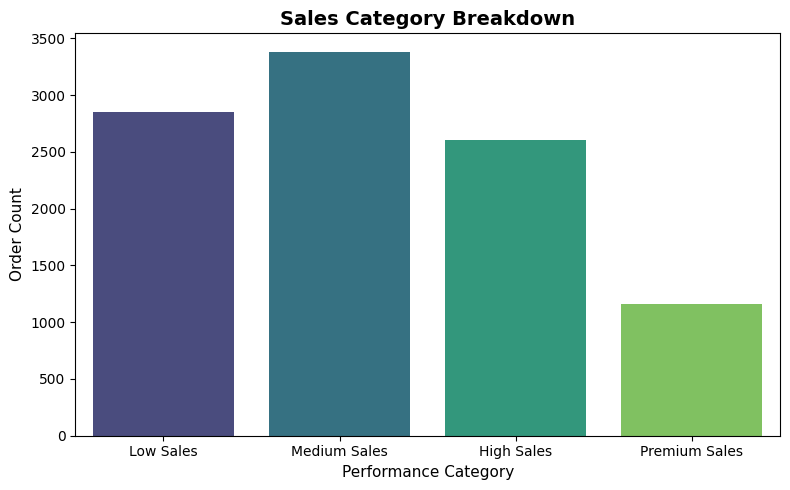

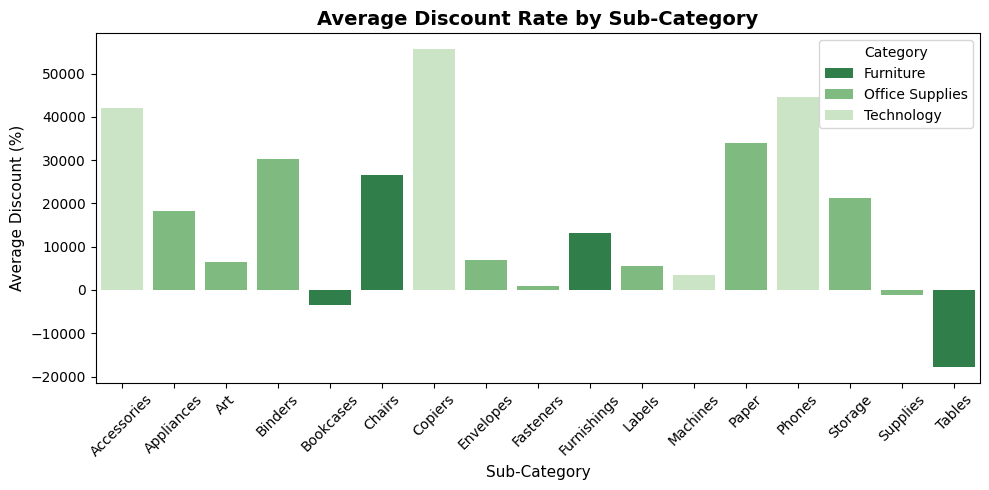

C:\Users\Sharkwar\AppData\Local\Temp\ipykernel_12444\1437747964.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Order_Size_Tier", y="Profit_Margin", palette="crest")


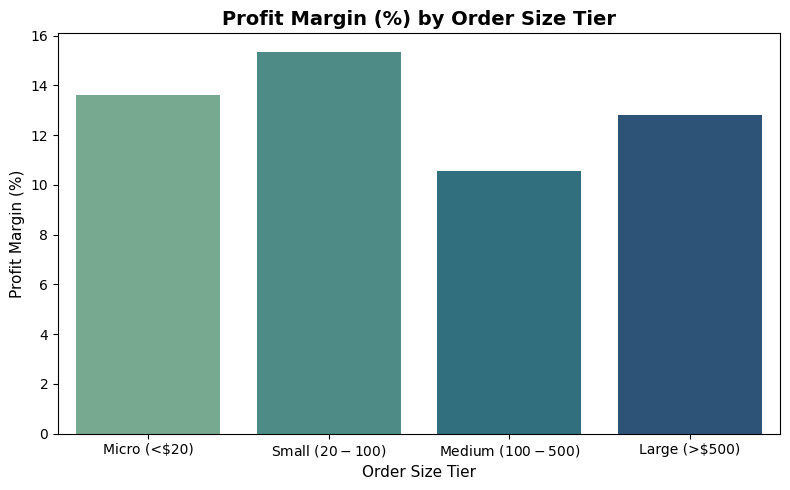

C:\Users\Sharkwar\AppData\Local\Temp\ipykernel_12444\206945962.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Top 20% Customers", "Bottom 80% Customers"],y=[top_20_share, bottom_80_share],palette=["lightGreen", "lightblue"],)


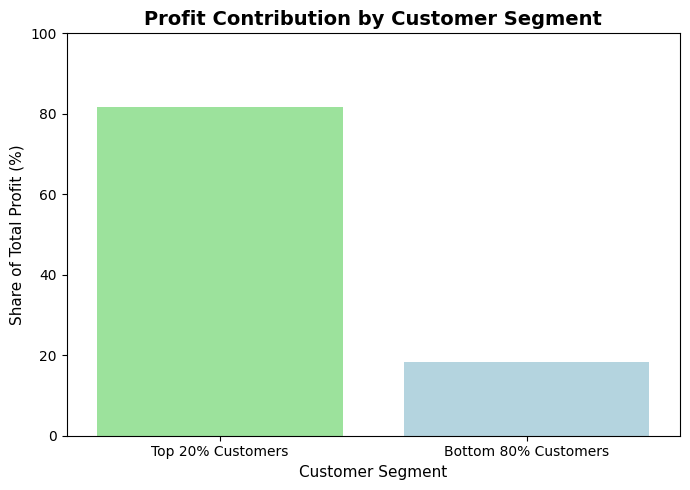

In [33]:
def final_pipe_line():
    """
    Data Cleaning And PreProcessing...
    """
    # Load raw data from the Excel spreadsheet
    df = pd.read_excel("Sample - Superstore 2019.xls")

    # Export raw data to a CSV format for compatibility and backup
    clean.export_to_CSV(df, "Sample - Superstore 2019")

    # Re-import from CSV while parsing specific date columns
    df = pd.read_csv("Sample - Superstore 2019.csv", parse_dates=["Order Date", "Ship Date"])

    # Remove redundant or unneeded columns like 'Row ID'
    df = clean.Delete_Columns(df, ["Row ID"])

    # Print DataFrame summary info including deep memory usage
    df.info(memory_usage="deep")

    # Standardize column names (casing, spaces, special characters)
    df = clean.Standardize_columns(df)

    # Handle missing or null values in the dataset
    df = clean.Null_Handling(df)

    # Detect and inspect data outliers using the Interquartile Range (IQR) method
    clean.detect_outliers_iqr(df)

    # Perform data type conversions for optimal memory footprint and accuracy
    df = clean.df_clean_conversion(df)

    # Save the cleaned and type-converted DataFrame to Parquet format
    clean.Save_as_parquet(df, "df_cleaned")

    """
    Feature Engineering and EDA
    
    """
    # Generate new features related to sales performance, margins, and order traits
    df = feature.engineer_sales_features(df)

    # Analyze discount distributions and their impacts on sales
    feature.analyze_discount(df)

    # Calculate and print the percentage of one-time buyers
    pct = feature.calculate_one_time_buyer_pct(df)
    print(f"One-Time Buyer Rate: {pct}%")

    # Analyze order size relative to overall profitability
    feature.analyze_order_size_profitability(df)

    # Analyze revenue concentration across customers or products
    feature.analyze_revenue_concentration(df)

    # Generate and preview time-series aggregated views
    feature.time_series(df).head(10)

    # Run validation checks on schema, features, and transformed subsets
    feature.validate_features(df)
    feature.validate_features(feature.analyze_discount(df))
    feature.validate_features(feature.analyze_order_size_profitability(df))
    feature.validate_features(feature.time_series(df))

    # Compute and display descriptive statistics for key numerical features
    feature.describtive_statistics(df)

    # Print value counts for the sales performance category classifications
    print(df["Sales Performance Category"].value_counts())

    # Display order counts grouped by shipping duration length
    print(df.groupby("Shipping_Duration").agg(Orders=("Shipping_Duration", "count")))

    # Display worst-performing geographic states
    feature.display_worst_performing_states(df)

    # Sort time-series data by profit margin to find the lowest performing periods
    feature.time_series(df).sort_values("Profit_Margin", ascending=True).head(10)

    # Display customers who are resulting in net financial losses
    feature.display_loss_making_customers(df)

    # Display shipping duration profitability analysis
    feature.display_shipping_duration_profitability(df)

    # Save the enhanced, feature-engineered DataFrame as a Parquet file
    feature.Save_as_parquet(df, "df_Feature")

    """
    Visualization
        
    """
    # Render high-level executive KPI dashboard
    display_kpi_dashboard(df)
    
    # Define primary numerical columns for statistical distributions
    num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
    
    # Display statistical distributions for numerical columns
    display_numerical_distributions(df, num_cols)

    # Generate and display correlation matrix heatmap
    display_correlation_heatmap(df, num_cols)

    # Run time series analysis visualizations
    Time_series_analysis(df)

    # Visualize shipping duration trends and metrics
    display_shipping_duration(df)

    # Display profit margin distribution plots
    display_profit_margin_dist(df)

    # Visualize sales performance categories
    display_sales_performance_category(df)

    # Display average discount breakdowns across product subcategories
    display_avg_discount_by_subcategory(df)

    # Display profit margins grouped by performance tiers
    display_profit_margin_by_tier(df)

    # Display revenue concentration bar plot (e.g., Pareto analysis)
    display_revenue_concentration_barplot(df)



    


final_pipe_line()
